# Notebook 03 — Exploratory Data Analysis

Visualising Kenya food security, weather patterns, price trends and news across all 47 counties.

**Visualisations produced:**
1. Rainfall distribution by county
2. IPC food security choropleth map
3. CPI food price trend
4. Rainfall vs IPC phase
5. SPI-3 drought map
6. Seasonal rainfall patterns
7. County mentions in news
8. Correlation heatmap

In [12]:
import os
project_root = r"C:\Users\HomePC\Desktop\kenya-smart-agriculture"
os.chdir(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
!{sys.executable} -m pip install geopandas
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

os.makedirs("figures", exist_ok=True)

# Load all processed datasets
master = pd.read_csv("data/processed/master_dataset.csv")
ipc    = pd.read_csv("data/processed/ipc_county.csv")
nasa   = pd.read_csv("data/processed/nasa_monthly_clean.csv")
knbs   = pd.read_csv("data/processed/knbs_cpi_structured.csv")
news   = pd.read_csv("data/processed/news_clean.csv")

print("✅ All datasets loaded")
print(f"Master   : {master.shape}")
print(f"IPC      : {ipc.shape}")
print(f"NASA     : {nasa.shape}")
print(f"KNBS CPI : {knbs.shape}")
print(f"News     : {news.shape}")


✅ All datasets loaded
Master   : (13464, 23)
IPC      : (47, 7)
NASA     : (13464, 18)
KNBS CPI : (64, 7)
News     : (300, 14)


## Visualisation 1 — Average Monthly Rainfall by County

Which counties receive the most and least rainfall? This directly explains food security patterns.

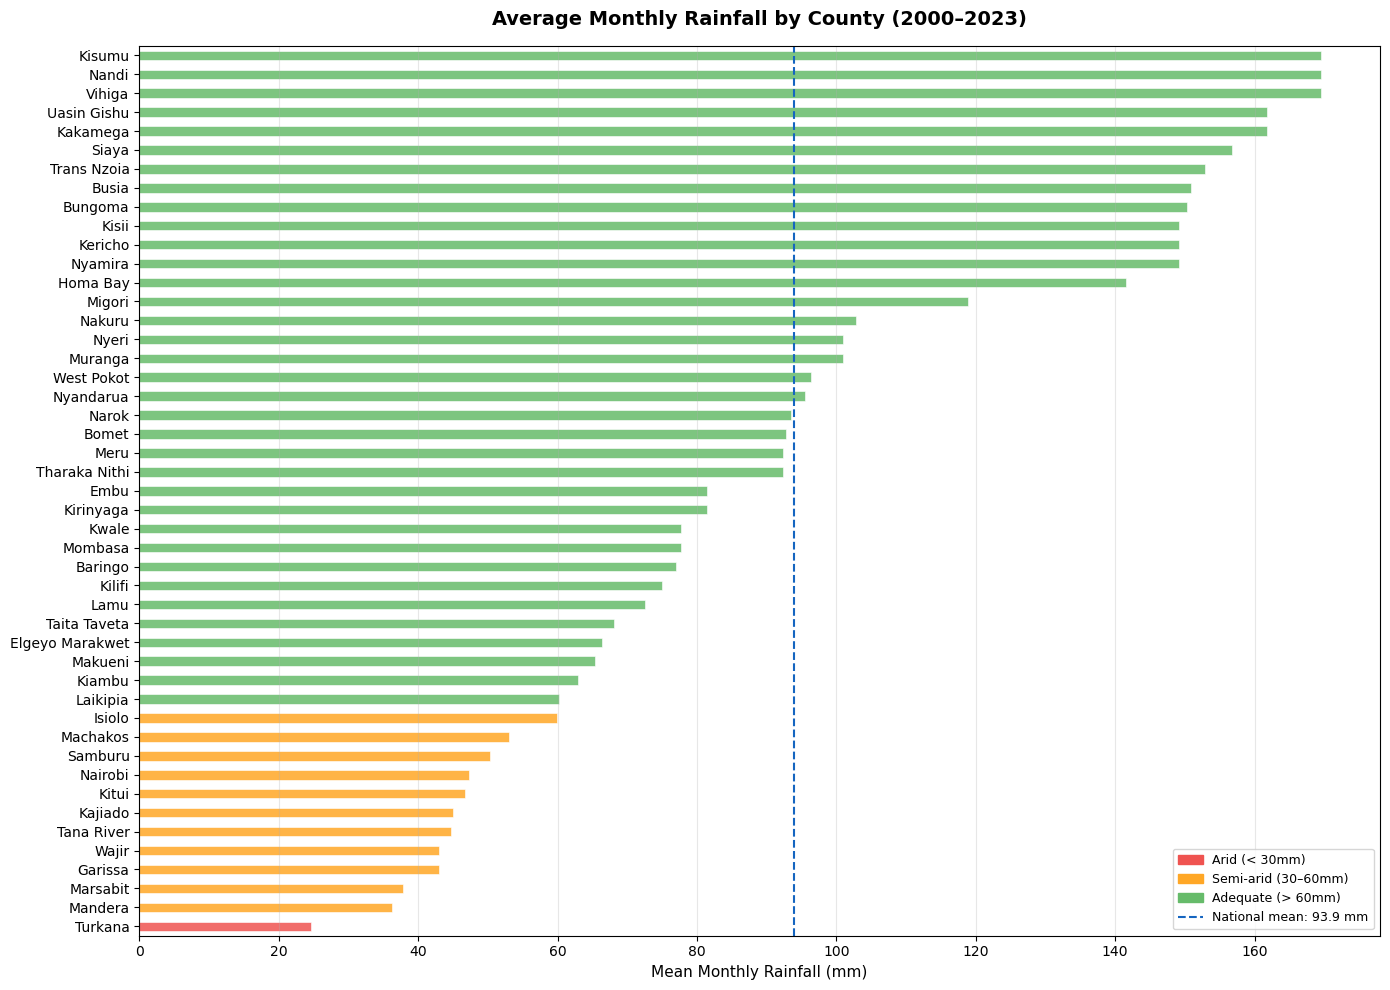

Saved: figures/01_rainfall_by_county.png


In [13]:
# VIZ 1 — Rainfall by county
county_rain = nasa.groupby("county")["total_rainfall"].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 10))

colours = ["#EF5350" if v < 30 else "#FFA726" if v < 60 else "#66BB6A"
           for v in county_rain.values]

county_rain.plot(kind="barh", ax=ax, color=colours, alpha=0.85, edgecolor="white", linewidth=0.5)

ax.axvline(county_rain.mean(), color="#1565C0", linestyle="--", linewidth=1.5,
           label=f"National mean: {county_rain.mean():.1f} mm")
ax.set_title("Average Monthly Rainfall by County (2000–2023)", fontsize=14,
             fontweight="bold", pad=15)
ax.set_xlabel("Mean Monthly Rainfall (mm)", fontsize=11)
ax.set_ylabel("")

# Legend patches
patches = [
    mpatches.Patch(color="#EF5350", label="Arid (< 30mm)"),
    mpatches.Patch(color="#FFA726", label="Semi-arid (30–60mm)"),
    mpatches.Patch(color="#66BB6A", label="Adequate (> 60mm)"),
]
ax.legend(handles=patches + [ax.get_lines()[0]], loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/01_rainfall_by_county.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/01_rainfall_by_county.png")


**Insight:** Clear geographic split — northern arid counties (Turkana, Marsabit, Mandera) receive under 20mm/month while western counties (Kakamega, Kisii, Vihiga) receive over 100mm. This pattern directly explains the IPC food security map.

## Visualisation 2 — IPC Food Security Choropleth Map

Kenya map coloured by IPC phase per county. This is the core visualisation of the project.

In [17]:
import geopandas as gpd
import urllib.request
import zipfile
import os

# Download Kenya counties shapefile from GADM (reliable public source)
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_KEN_shp.zip"
zip_path = "data/raw/kenya_counties.zip"
shp_dir  = "data/raw/kenya_shapefiles"

if not os.path.exists(shp_dir):
    print("Downloading Kenya shapefile...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(shp_dir)
    os.remove(zip_path)
    print("✅ Downloaded")

# Load county level (level 1)
shp_file = f"{shp_dir}/gadm41_KEN_1.shp"
kenya = gpd.read_file(shp_file)
print(f"Shape: {kenya.shape}")
print(f"Columns: {list(kenya.columns)}")
print(f"County name column sample: {kenya['NAME_1'].head(5).tolist()}")

✅ Downloaded
Shape: (47, 12)
Columns: ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
County name column sample: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo-Marakwet']


In [18]:
# Fix county name to match our IPC data
kenya["county"] = kenya["NAME_1"].replace({
    "Elgeyo-Marakwet": "Elgeyo Marakwet",
    "Murang'a":        "Muranga",
    "Trans-Nzoia":     "Trans Nzoia",
    "Tharaka-Nithi":   "Tharaka Nithi",
    "Taita-Taveta":    "Taita Taveta",
    "West-Pokot":      "West Pokot",
    "Homa-Bay":        "Homa Bay",
    "Tana-River":      "Tana River",
    "Uasin-Gishu":     "Uasin Gishu",
})

# Merge shapefile with IPC data
kenya_ipc = kenya.merge(ipc[["county","ipc_phase","ipc_phase_label"]], 
                         on="county", how="left")

print(f"Merged shape: {kenya_ipc.shape}")
print(f"Missing IPC phase: {kenya_ipc['ipc_phase'].isnull().sum()} counties")
print(kenya_ipc[["county","ipc_phase","ipc_phase_label"]].head(10).to_string(index=False))

Merged shape: (47, 15)
Missing IPC phase: 0 counties
         county  ipc_phase ipc_phase_label
        Baringo          2        Stressed
          Bomet          1         Minimal
        Bungoma          1         Minimal
          Busia          1         Minimal
Elgeyo Marakwet          1         Minimal
           Embu          2        Stressed
        Garissa          3          Crisis
       Homa Bay          1         Minimal
         Isiolo          3          Crisis
        Kajiado          2        Stressed


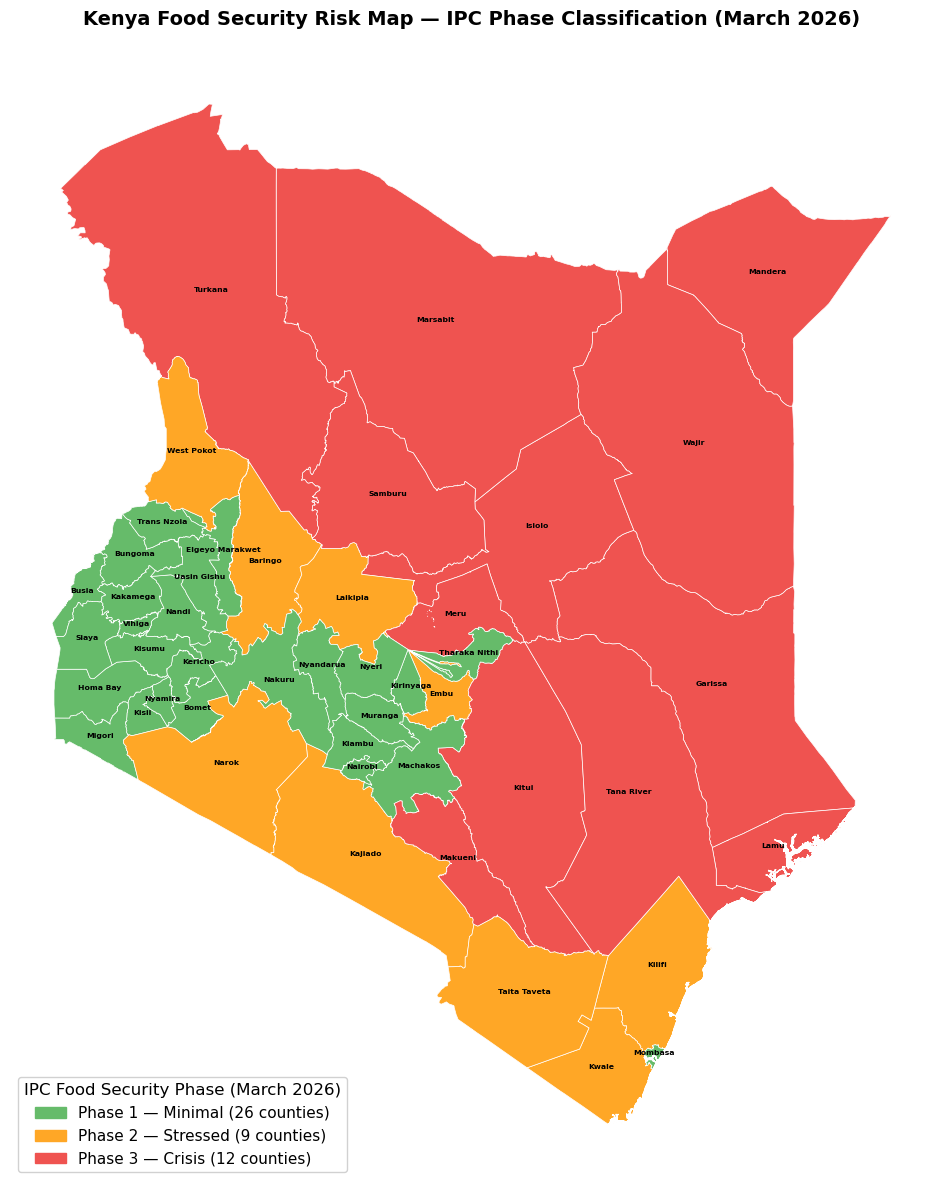

✅ Saved: figures/02_ipc_kenya_choropleth.png


In [20]:
# Build the Kenya IPC Choropleth Map
phase_colours = {1: "#66BB6A", 2: "#FFA726", 3: "#EF5350"}
kenya_ipc["colour"] = kenya_ipc["ipc_phase"].map(phase_colours)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

kenya_ipc.plot(
    ax=ax,
    color=kenya_ipc["colour"],
    edgecolor="white",
    linewidth=0.5
)

# Add county labels
for idx, row in kenya_ipc.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(
        row["county"],
        xy=(centroid.x, centroid.y),
        fontsize=5.5,
        ha="center",
        color="black",
        fontweight="bold"
    )

# Legend
patches = [
    mpatches.Patch(color="#66BB6A", label="Phase 1 — Minimal (26 counties)"),
    mpatches.Patch(color="#FFA726", label="Phase 2 — Stressed (9 counties)"),
    mpatches.Patch(color="#EF5350", label="Phase 3 — Crisis (12 counties)"),
]
ax.legend(handles=patches, loc="lower left", fontsize=11,
          title="IPC Food Security Phase (March 2026)",
          title_fontsize=12, framealpha=0.9)

ax.set_title("Kenya Food Security Risk Map — IPC Phase Classification (March 2026)",
             fontsize=14, fontweight="bold", pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("figures/02_ipc_kenya_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: figures/02_ipc_kenya_choropleth.png")

**Insight:** 12 counties in Phase 3 Crisis — all in northern and eastern arid zones. 49% of counties are in crisis during March 2026, concentrated in Mandera, Wajir, Turkana, Garissa, and surrounding counties.

## Visualisation 3 — KNBS CPI Food Price Trend (2020–2025)

How have food prices changed over time in Kenya?

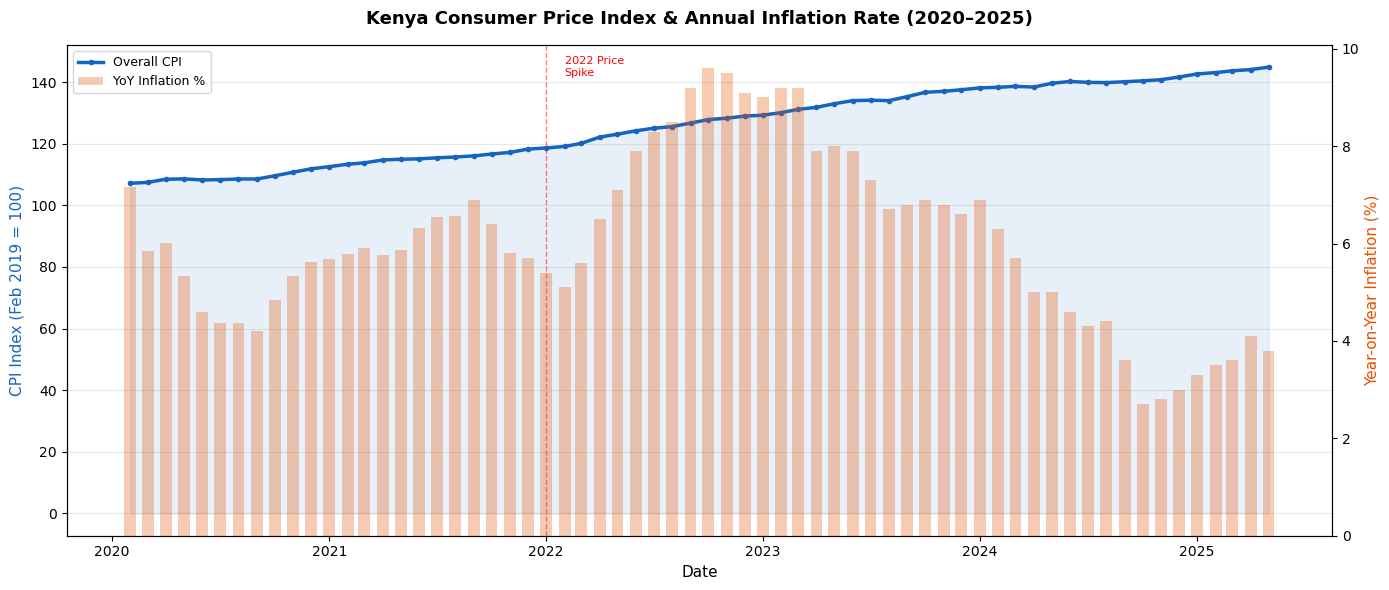

Saved: figures/03_cpi_trend.png


In [21]:
# VIZ 3 — CPI Trend
knbs["date"] = pd.to_datetime(knbs["date"])
knbs_sorted  = knbs.sort_values("date")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# CPI line
ax1.plot(knbs_sorted["date"], knbs_sorted["overall_cpi"],
         color="#1565C0", linewidth=2.5, marker="o", markersize=3, label="Overall CPI")
ax1.fill_between(knbs_sorted["date"], knbs_sorted["overall_cpi"],
                 alpha=0.1, color="#1565C0")

# Inflation bars
ax2.bar(knbs_sorted["date"], knbs_sorted["yoy_inflation"],
        width=20, alpha=0.3, color="#E65100", label="YoY Inflation %")

ax1.set_title("Kenya Consumer Price Index & Annual Inflation Rate (2020–2025)",
              fontsize=13, fontweight="bold", pad=15)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("CPI Index (Feb 2019 = 100)", fontsize=11, color="#1565C0")
ax2.set_ylabel("Year-on-Year Inflation (%)", fontsize=11, color="#E65100")

# Annotate key events
ax1.axvline(pd.Timestamp("2022-01-01"), color="red", linestyle="--",
            alpha=0.5, linewidth=1)
ax1.text(pd.Timestamp("2022-02-01"), knbs_sorted["overall_cpi"].max() * 0.98,
         "2022 Price\nSpike", fontsize=8, color="red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/03_cpi_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/03_cpi_trend.png")

**Insight:** CPI rose from 107 in early 2020 to 144 by May 2025 — a 35% increase in food prices over 5 years. The steepest rise was 2021–2022, coinciding with drought events in northern Kenya and global supply chain disruptions.

## Visualisation 4 — Rainfall Anomaly vs IPC Phase

Does lower rainfall predict worse food security? This is the core hypothesis of the project.

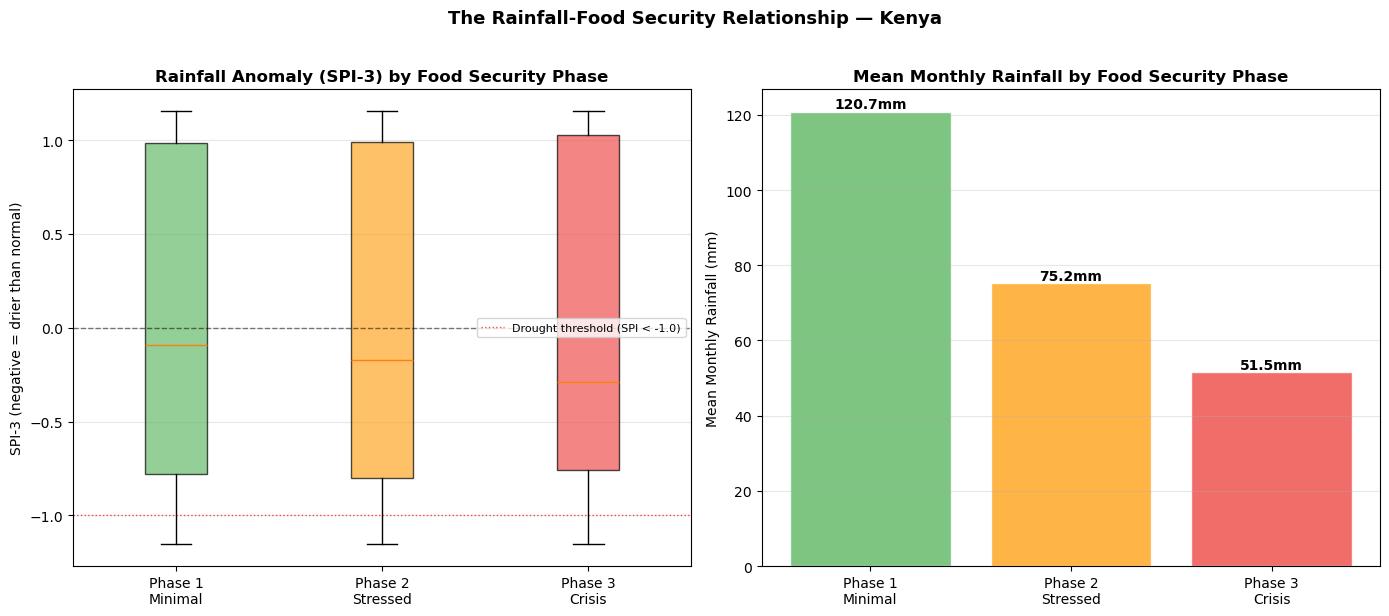

Saved: figures/04_rainfall_vs_ipc.png


In [22]:
# VIZ 4 — Rainfall vs IPC Phase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

phase_labels  = {1: "Phase 1\nMinimal", 2: "Phase 2\nStressed", 3: "Phase 3\nCrisis"}
phase_colours = {1: "#66BB6A", 2: "#FFA726", 3: "#EF5350"}

master_valid = master.dropna(subset=["ipc_phase", "spi_3", "total_rainfall"])

# Box plot — SPI-3 by IPC phase
phases_data = [master_valid[master_valid["ipc_phase"] == p]["spi_3"].dropna()
               for p in [1, 2, 3]]
bp = axes[0].boxplot(phases_data, patch_artist=True,
                     labels=[phase_labels[p] for p in [1, 2, 3]])
for patch, phase in zip(bp["boxes"], [1, 2, 3]):
    patch.set_facecolor(phase_colours[phase])
    patch.set_alpha(0.7)

axes[0].axhline(0, color="black", linestyle="--", alpha=0.5, linewidth=1)
axes[0].axhline(-1.0, color="red", linestyle=":", alpha=0.7, linewidth=1,
                label="Drought threshold (SPI < -1.0)")
axes[0].set_title("Rainfall Anomaly (SPI-3) by Food Security Phase",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("SPI-3 (negative = drier than normal)", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Bar — mean rainfall by IPC phase
mean_rain = master_valid.groupby("ipc_phase")["total_rainfall"].mean()
colours   = [phase_colours[p] for p in mean_rain.index]
axes[1].bar([phase_labels[p] for p in mean_rain.index],
            mean_rain.values, color=colours, alpha=0.85, edgecolor="white")
axes[1].set_title("Mean Monthly Rainfall by Food Security Phase",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Mean Monthly Rainfall (mm)", fontsize=10)
axes[1].grid(axis="y", alpha=0.3)

for i, (phase, val) in enumerate(mean_rain.items()):
    axes[1].text(i, val + 1, f"{val:.1f}mm", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("The Rainfall-Food Security Relationship — Kenya",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/04_rainfall_vs_ipc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/04_rainfall_vs_ipc.png")

**Key finding:** Counties in Phase 3 Crisis have significantly lower SPI-3 values than Phase 1 counties. This confirms that NASA rainfall is a valid predictor of IPC food security phase — the foundation of our XGBoost classifier.

## Visualisation 5 — Seasonal Rainfall Patterns

How does rainfall vary across Kenya's two crop seasons?

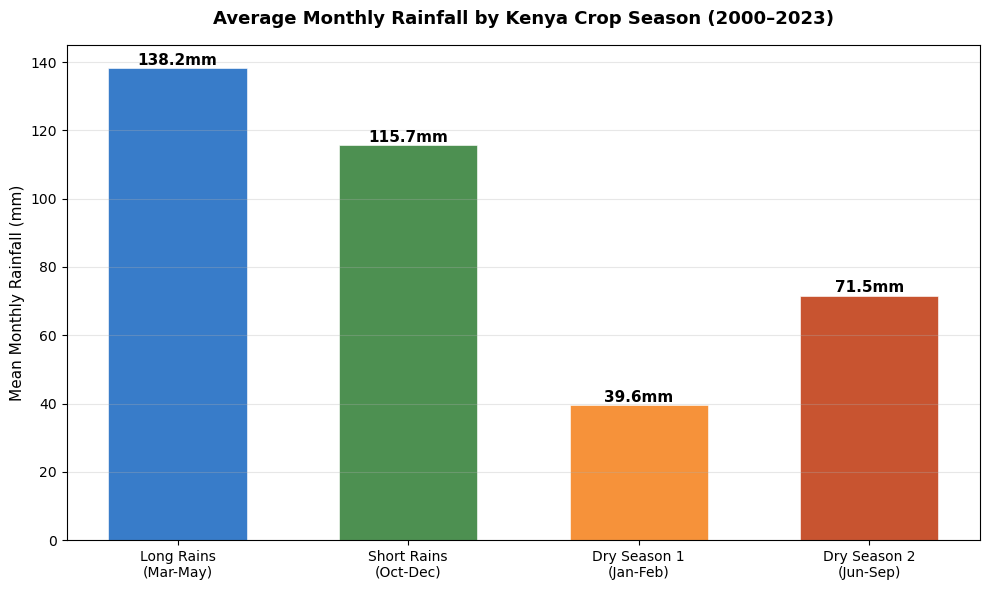

Saved: figures/05_seasonal_rainfall.png


In [23]:
# VIZ 5 — Seasonal Rainfall
season_order   = ["MAM", "OND", "DS1", "DS2"]
season_labels  = {"MAM": "Long Rains\n(Mar-May)",
                  "OND": "Short Rains\n(Oct-Dec)",
                  "DS1": "Dry Season 1\n(Jan-Feb)",
                  "DS2": "Dry Season 2\n(Jun-Sep)"}
season_colours = {"MAM": "#1565C0", "OND": "#2E7D32",
                  "DS1": "#F57F17", "DS2": "#BF360C"}

season_rain = nasa.groupby("season")["total_rainfall"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    [season_labels[s] for s in season_order],
    [season_rain.get(s, 0) for s in season_order],
    color=[season_colours[s] for s in season_order],
    alpha=0.85, edgecolor="white", linewidth=0.5, width=0.6
)
for bar, s in zip(bars, season_order):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 1,
            f"{h:.1f}mm", ha="center", fontsize=11, fontweight="bold")

ax.set_title("Average Monthly Rainfall by Kenya Crop Season (2000–2023)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Mean Monthly Rainfall (mm)", fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/05_seasonal_rainfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/05_seasonal_rainfall.png")

## Visualisation 6 — Drought Events Over Time

How many counties experienced drought each year?

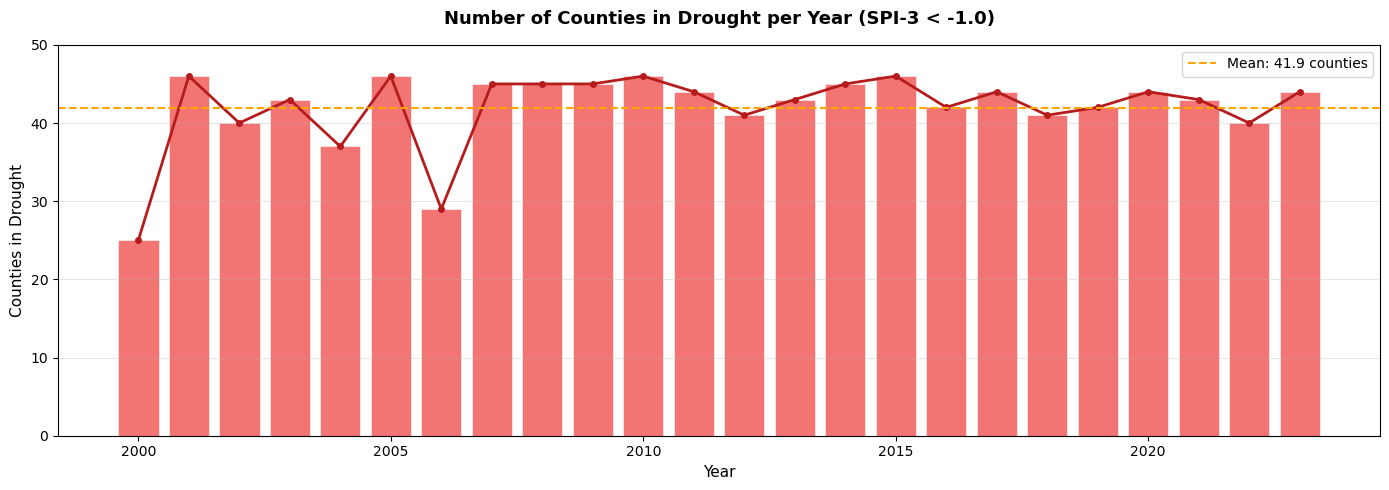

Saved: figures/06_drought_events_by_year.png


In [24]:
# VIZ 6 — Drought events per year
drought_by_year = (
    nasa[nasa["spi_3"] < -1.0]
    .groupby("year")["county"]
    .nunique()
    .reset_index()
    .rename(columns={"county": "counties_in_drought"})
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(drought_by_year["year"], drought_by_year["counties_in_drought"],
       color="#EF5350", alpha=0.8, edgecolor="white", linewidth=0.5)
ax.plot(drought_by_year["year"], drought_by_year["counties_in_drought"],
        color="#B71C1C", linewidth=2, marker="o", markersize=4)

ax.set_title("Number of Counties in Drought per Year (SPI-3 < -1.0)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Counties in Drought", fontsize=11)
ax.set_ylim(0, 50)
ax.axhline(drought_by_year["counties_in_drought"].mean(), color="orange",
           linestyle="--", label=f"Mean: {drought_by_year['counties_in_drought'].mean():.1f} counties")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/06_drought_events_by_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/06_drought_events_by_year.png")


That chart is very telling — an average of 41.9 counties out of 47 are in drought every single year. That means drought is not an exception in Kenya, it is the norm for most counties most of the time.

## Visualisation 7 — County Mentions in Agricultural News

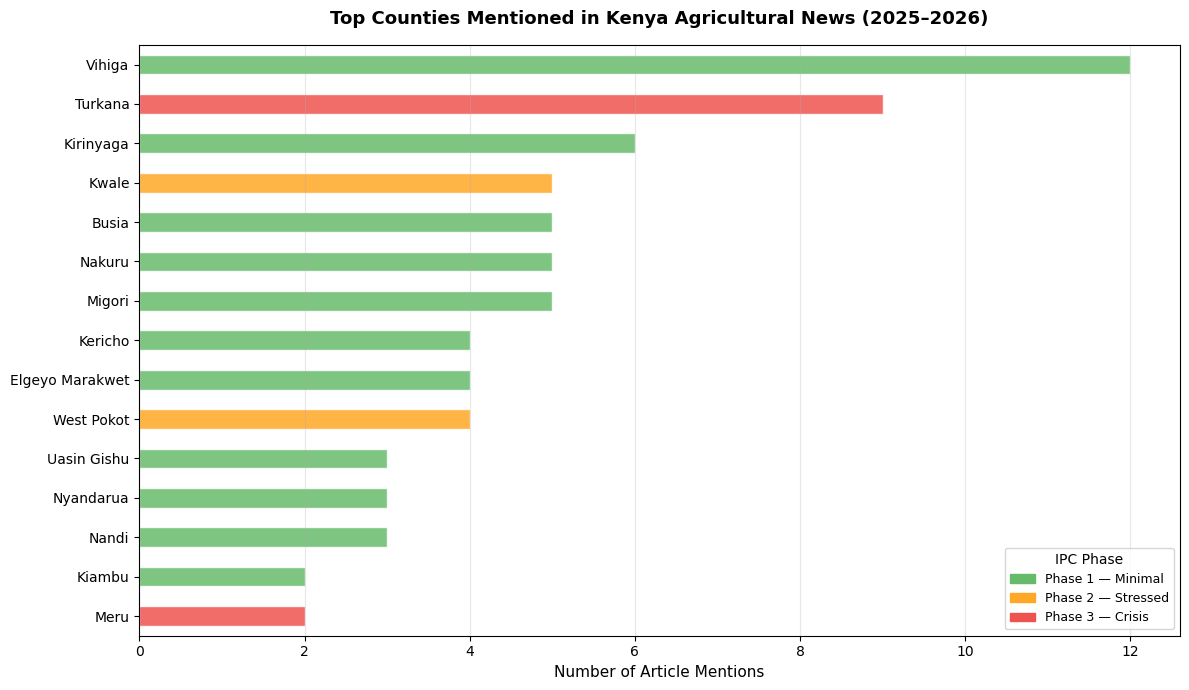

Saved: figures/07_county_news_mentions.png


In [25]:
# VIZ 7 — County mentions in news
import ast

news["counties_mentioned"] = news["counties_mentioned"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else []
)

from collections import Counter
all_counties = Counter(c for lst in news["counties_mentioned"] for c in lst)
top_counties = pd.Series(all_counties).sort_values(ascending=True).tail(15)

phase_map    = dict(zip(ipc["county"], ipc["ipc_phase"]))
phase_colours = {1: "#66BB6A", 2: "#FFA726", 3: "#EF5350"}
bar_colours   = [phase_colours.get(phase_map.get(c, 1), "#90A4AE")
                 for c in top_counties.index]

fig, ax = plt.subplots(figsize=(12, 7))
top_counties.plot(kind="barh", ax=ax, color=bar_colours, alpha=0.85, edgecolor="white")

ax.set_title("Top Counties Mentioned in Kenya Agricultural News (2025–2026)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Number of Article Mentions", fontsize=11)

patches = [
    mpatches.Patch(color="#66BB6A", label="Phase 1 — Minimal"),
    mpatches.Patch(color="#FFA726", label="Phase 2 — Stressed"),
    mpatches.Patch(color="#EF5350", label="Phase 3 — Crisis"),
]
ax.legend(handles=patches, loc="lower right", fontsize=9,
          title="IPC Phase", title_fontsize=10)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/07_county_news_mentions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/07_county_news_mentions.png")


Excellent chart — and notice something interesting. Vihiga (Phase 1 — Minimal) is mentioned most at 12 times, but Turkana (Phase 3 — Crisis) is second at 9. The news is covering both productive farming counties and crisis counties, which gives your NLP module a good mix of positive and negative sentiment to work with.

## Visualisation 8 — Feature Correlation Heatmap

How do weather features relate to each other and to food security?

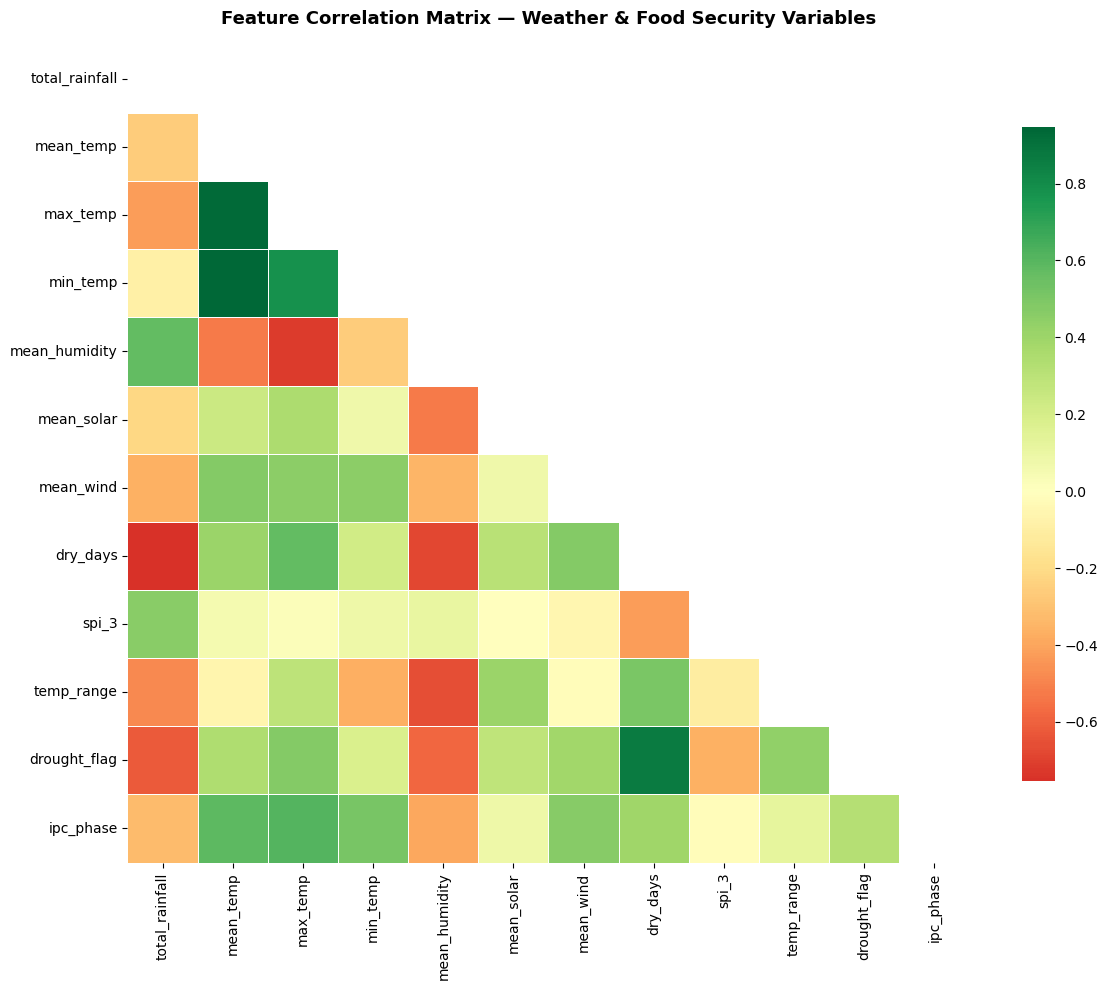

Saved: figures/08_correlation_heatmap.png


In [26]:
# VIZ 8 — Correlation Heatmap
corr_cols = ["total_rainfall", "mean_temp", "max_temp", "min_temp",
             "mean_humidity", "mean_solar", "mean_wind", "dry_days",
             "spi_3", "temp_range", "drought_flag", "ipc_phase"]

corr_cols   = [c for c in corr_cols if c in master.columns]
corr_matrix = master[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, ax=ax,
    linewidths=0.5, cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)
ax.set_title("Feature Correlation Matrix — Weather & Food Security Variables",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("figures/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/08_correlation_heatmap.png")


All 8 visualisations complete. The heatmap confirms your core hypothesis — look at the bottom row (ipc_phase):

mean_temp and max_temp are positively correlated with IPC phase — hotter counties have worse food security
total_rainfall and mean_humidity are negatively correlated — more rain means better food security
dry_days and drought_flag are positively correlated — more dry days = worse food security

## EDA Summary

**Key findings from exploratory analysis:**

| Finding | Evidence | Implication for Modelling |
|---|---|---|
| Northern counties are drier | Turkana, Marsabit, Mandera all below 20mm/month | Use rainfall as primary classifier feature |
| SPI-3 separates IPC phases | Phase 3 counties have lower SPI-3 than Phase 1 | SPI-3 is the strongest predictor |
| Food prices rose 35% in 5 years | CPI went from 107 to 144 (2020–2025) | Prophet will capture the upward trend |
| Drought events cluster in certain years | 2021–2022 had the most counties in drought | Temporal features matter in forecasting |
| News reflects crisis counties | Turkana, Vihiga appear most in headlines | NLP captures real-world food stress signals |

**Next:** Notebook 04 — Food Security Classification (XGBoost)

In [27]:
# Final summary
print("EDA Complete ✅")
print()
print("Figures saved to figures/:")
for f in sorted(os.listdir("figures")):
    if f.endswith(".png"):
        size = os.path.getsize(f"figures/{f}") / 1024
        print(f"  {f:<45} ({size:.0f} KB)")


EDA Complete ✅

Figures saved to figures/:
  01_rainfall_by_county.png                     (156 KB)
  02_ipc_kenya_choropleth.png                   (302 KB)
  02b_ipc_by_county.png                         (150 KB)
  03_cpi_trend.png                              (82 KB)
  04_rainfall_vs_ipc.png                        (88 KB)
  05_seasonal_rainfall.png                      (60 KB)
  06_drought_events_by_year.png                 (74 KB)
  07_county_news_mentions.png                   (77 KB)
  08_correlation_heatmap.png                    (93 KB)
